In [ ]:
# -*- coding: utf-8 -*-
"""
Phi-4-mini-instruct QLoRA  Evaluation Notebook v3
=====================================================
Points to the v3 fine-tuned model saved by phi4_legal_finetune_v3.py
Metrics: Accuracy, Precision, Recall, F1 (macro & weighted)
         Per-class report + Confusion matrix PNG
"""

'\nPhi-4-mini-instruct QLoRA  —  Evaluation Notebook v3\n=====================================================\nPoints to the v3 fine-tuned model saved by phi4_legal_finetune_v3.py\nMetrics: Accuracy, Precision, Recall, F1 (macro & weighted)\n         Per-class report + Confusion matrix PNG\n'

In [ ]:
# Install dependencies
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "torch", "torchvision", "torchaudio",
                "--index-url", "https://download.pytorch.org/whl/cu124"],
               check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers==4.48.1",
                "accelerate==1.3.0",
                "peft==0.14.0",
                "bitsandbytes>=0.43.0",
                "datasets>=2.18.0",
                "scikit-learn",
                "pandas", "numpy",
                "sentencepiece",
                "matplotlib", "seaborn"],
               check=True)

print("✅  Packages ready.")

✅  Packages ready.


In [ ]:
# Mount Drive & HuggingFace login
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from huggingface_hub import login
HF_TOKEN = "hf_****************"
login(HF_TOKEN)
print("✅  Drive mounted & HF login done.")

✅  Drive mounted & HF login done.


In [ ]:
#  Imports

import os, json, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

print("✅  Imports done.")
print("    GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")


✅  Imports done.
    GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Paths  (v3 directories)
# ===========================================================================
BASE_MODEL_ID   = "microsoft/Phi-4-mini-instruct"

PROJECT_DIR     = "/content/drive/MyDrive/phi4_thesis_HuggingFace_v3"
QLORA_DIR       = os.path.join(PROJECT_DIR, "qlora_model")
SPLITS_DIR      = os.path.join(PROJECT_DIR, "splits")
METRICS_DIR     = os.path.join(PROJECT_DIR, "metrics")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "predictions")

for folder in [METRICS_DIR, PREDICTIONS_DIR]:
    os.makedirs(folder, exist_ok=True)

# Load label list saved during training
labels_path = os.path.join(QLORA_DIR, "labels.json")
if not os.path.exists(labels_path):
    labels_path = os.path.join(SPLITS_DIR, "labels.json")

with open(labels_path) as f:
    LABELS = json.load(f)

LABELS_LOWER = [l.lower().strip() for l in LABELS]

print("QLORA_DIR :", QLORA_DIR)
print("Labels    :", LABELS)

QLORA_DIR : /content/drive/MyDrive/phi4_thesis_HuggingFace_v3/qlora_model
Labels    : ['applied', 'cited', 'considered', 'discussed', 'distinguished', 'followed', 'referred to']


In [ ]:
# Load test split

TEXT_COL  = "case_text"
LABEL_COL = "case_outcome"

test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))
test_df[TEXT_COL]  = test_df[TEXT_COL].astype(str).str.strip()
test_df[LABEL_COL] = test_df[LABEL_COL].astype(str).str.strip().str.lower()
test_df = test_df[test_df[LABEL_COL].isin(LABELS_LOWER)].reset_index(drop=True)

print(f"Test samples : {len(test_df)}")
print("\nLabel distribution (natural — not rebalanced):")
print(test_df[LABEL_COL].value_counts().to_string())

Test samples : 1836

Label distribution (natural — not rebalanced):
case_outcome
cited            907
referred to      318
applied          194
followed         164
considered       125
discussed         79
distinguished     49


In [ ]:
# ===========================================================================
# Load tokenizer
# ===========================================================================
tokenizer = AutoTokenizer.from_pretrained(QLORA_DIR, trust_remote_code=True)
tokenizer.model_max_length = 2048
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

print("✅  Tokenizer loaded.  Pad token:", repr(tokenizer.pad_token))

✅  Tokenizer loaded.  Pad token: '<|endoftext|>'


In [ ]:
# ===========================================================================
# Load base model in 4-bit & attach LoRA adapter
# ===========================================================================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading base model {BASE_MODEL_ID} in 4-bit …")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    use_cache=True,
    attn_implementation="eager",
)

print("Attaching LoRA adapter from:", QLORA_DIR)
model = PeftModel.from_pretrained(base_model, QLORA_DIR)

# Merge adapter into base model — eliminates all tensor shape issues
# during generation with Phi-4-mini-instruct
print("Merging LoRA adapter into base model …")
model = model.merge_and_unload()
model.eval()
print("✅  Model ready for inference.")

Loading base model microsoft/Phi-4-mini-instruct in 4-bit …


config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Attaching LoRA adapter from: /content/drive/MyDrive/phi4_thesis_HuggingFace_v3/qlora_model
Merging LoRA adapter into base model …


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:355: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


✅  Model ready for inference.


In [ ]:
# Prompt builder  (matches v3 training prompt exactly)

SYSTEM_MSG = (
    "You are a legal assistant specialising in case-outcome classification. "
    "Analyse the provided case text and return exactly one label from the "
    "allowed list — nothing else.\n\n"
    "Label definitions:\n"
    "- cited: The case was cited as authority without further treatment.\n"
    "- applied: The legal principle from the case was directly applied to the facts.\n"
    "- followed: The decision was followed as binding or persuasive precedent.\n"
    "- considered: The case was examined and taken into account but not necessarily followed.\n"
    "- discussed: The case was discussed in detail, analysing its reasoning or implications.\n"
    "- distinguished: The case was differentiated on its facts or legal principles.\n"
    "- referred to: The case was briefly mentioned as a passing reference.\n"
)
LABEL_STR = ", ".join(LABELS)

def build_inference_prompt(case_text: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {
            "role": "user",
            "content": (
                f"Case Text:\n{case_text}\n\n"
                f"Allowed labels: {LABEL_STR}.\n"
                "What is the outcome of this case? Return only the label."
            ),
        },
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

In [ ]:
# Label extraction helper

def extract_label(generated_text: str) -> str:
    if "<|assistant|>" in generated_text:
        generated_text = generated_text.split("<|assistant|>")[-1]

    cleaned = generated_text.strip().lower()
    cleaned = re.sub(r"[.\n\r]+$", "", cleaned).strip()

    # Exact match
    if cleaned in LABELS_LOWER:
        return cleaned

    # Substring match — check longer labels first to avoid partial hits
    for label in sorted(LABELS_LOWER, key=len, reverse=True):
        if label in cleaned:
            return label

    return "unknown"

In [ ]:
# Manual token-by-token generation
#
#   model.generate() has a tensor dimension bug with Phi-4-mini in
#   transformers 4.48.1.  Manual greedy decoding bypasses it entirely.
#   On A100: ~0.3–0.5 s/sample → 1836 samples ≈ 15–25 min.
# ===========================================================================
MAX_NEW_TOKENS = 20

def manual_generate(prompt_text: str) -> str:
    """Greedy token-by-token decode — avoids Phi-4-mini generate() bug."""
    inputs    = tokenizer(prompt_text, return_tensors="pt",
                          truncation=True, max_length=2048)
    generated = inputs["input_ids"].to(model.device)

    with torch.inference_mode():
        for _ in range(MAX_NEW_TOKENS):
            outputs     = model(input_ids=generated)
            next_logits = outputs.logits[0, -1, :]
            next_token  = torch.argmax(next_logits).item()

            if next_token == tokenizer.eos_token_id:
                break

            generated = torch.cat(
                [generated,
                 torch.tensor([[next_token]], device=model.device)],
                dim=1,
            )

    input_len = inputs["input_ids"].shape[1]
    new_ids   = generated[0, input_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


all_predictions  = []
all_ground_truth = test_df[LABEL_COL].tolist()
all_raw_outputs  = []
n         = len(test_df)
LOG_EVERY = 100

print(f"Running inference on {n} samples …\n")

for idx in range(n):
    prompt = build_inference_prompt(test_df[TEXT_COL].iloc[idx])
    raw    = manual_generate(prompt)

    all_raw_outputs.append(raw)
    all_predictions.append(extract_label(raw))

    if (idx + 1) % LOG_EVERY == 0 or (idx + 1) == n:
        pct = 100 * (idx + 1) / n
        print(f"  [{idx+1:>4}/{n}]  ({pct:5.1f}%)  last raw: {repr(raw[:60])}")

print(f"\n✅  Inference complete.  Total predictions: {len(all_predictions)}")

Running inference on 1836 samples …

  [ 100/1836]  (  5.4%)  last raw: 'consideredIn the context of the provided case text, identify'
  [ 200/1836]  ( 10.9%)  last raw: 'consideredIn the context of the provided case text, the Cour'
  [ 300/1836]  ( 16.3%)  last raw: 'citedIn the case of S1234/2004 v Minister for Immigration an'
  [ 400/1836]  ( 21.8%)  last raw: 'followedIn the context of the provided case text, the label '
  [ 500/1836]  ( 27.2%)  last raw: 'citedIn the case of Smith v Jones, the court had to determin'
  [ 600/1836]  ( 32.7%)  last raw: "consideredThe meaning of 'information' in the context of ss "
  [ 700/1836]  ( 38.1%)  last raw: 'followedCase Text:\nI should note that, even if the Kabi Kabi'
  [ 800/1836]  ( 43.6%)  last raw: 'followedCase Text:\ncontraventions on 15, 17 and 21 February'
  [ 900/1836]  ( 49.0%)  last raw: 'followedThe provided text does not contain the outcome of th'
  [1000/1836]  ( 54.5%)  last raw: 'citedCase Text:\nIn the matter of Smith v Jo

In [ ]:
# Compute & print metrics
# ===========================================================================
n_unknown = all_predictions.count("unknown")
print(f"\nUnrecognised outputs ('unknown'): {n_unknown} / {n}  "
      f"({100*n_unknown/n:.1f}%)\n")

acc = accuracy_score(all_ground_truth, all_predictions)

prec_macro,   rec_macro,   f1_macro,   _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average="macro",    zero_division=0)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average="weighted", zero_division=0)

print("=" * 58)
print("      EVALUATION RESULTS — QLoRA Phi-4-mini  (v3)")
print("=" * 58)
print(f"  Accuracy             : {acc:.4f}  ({acc*100:.2f}%)")
print()
print(f"  Precision  (macro)   : {prec_macro:.4f}")
print(f"  Recall     (macro)   : {rec_macro:.4f}")
print(f"  F1-score   (macro)   : {f1_macro:.4f}")
print()
print(f"  Precision  (weighted): {prec_weighted:.4f}")
print(f"  Recall     (weighted): {rec_weighted:.4f}")
print(f"  F1-score   (weighted): {f1_weighted:.4f}")
print("=" * 58)

report_labels = LABELS_LOWER + (["unknown"] if n_unknown > 0 else [])
print("\n── Per-class Classification Report ──\n")
print(classification_report(
    all_ground_truth, all_predictions,
    labels=report_labels,
    zero_division=0,
))


Unrecognised outputs ('unknown'): 48 / 1836  (2.6%)

      EVALUATION RESULTS — QLoRA Phi-4-mini  (v3)
  Accuracy             : 0.3655  (36.55%)

  Precision  (macro)   : 0.2358
  Recall     (macro)   : 0.1457
  F1-score   (macro)   : 0.1361

  Precision  (weighted): 0.3659
  Recall     (weighted): 0.3655
  F1-score   (weighted): 0.3236

── Per-class Classification Report ──

               precision    recall  f1-score   support

      applied       0.11      0.01      0.02       194
        cited       0.52      0.66      0.59       907
   considered       0.03      0.02      0.02       125
    discussed       0.07      0.01      0.02        79
distinguished       0.70      0.14      0.24        49
     followed       0.09      0.29      0.14       164
  referred to       0.37      0.03      0.06       318
      unknown       0.00      0.00      0.00         0

     accuracy                           0.37      1836
    macro avg       0.24      0.15      0.14      1836
 weighted avg

In [ ]:
# Save metrics JSON
# ===========================================================================
metrics_dict = {
    "accuracy":           round(acc, 6),
    "precision_macro":    round(prec_macro, 6),
    "recall_macro":       round(rec_macro, 6),
    "f1_macro":           round(f1_macro, 6),
    "precision_weighted": round(prec_weighted, 6),
    "recall_weighted":    round(rec_weighted, 6),
    "f1_weighted":        round(f1_weighted, 6),
    "n_test_samples":     n,
    "n_unknown_preds":    n_unknown,
    "labels":             LABELS_LOWER,
}

metrics_path = os.path.join(METRICS_DIR, "test_evaluation_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=2)
print(f"✅  Metrics saved to: {metrics_path}")

✅  Metrics saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace_v3/metrics/test_evaluation_metrics.json


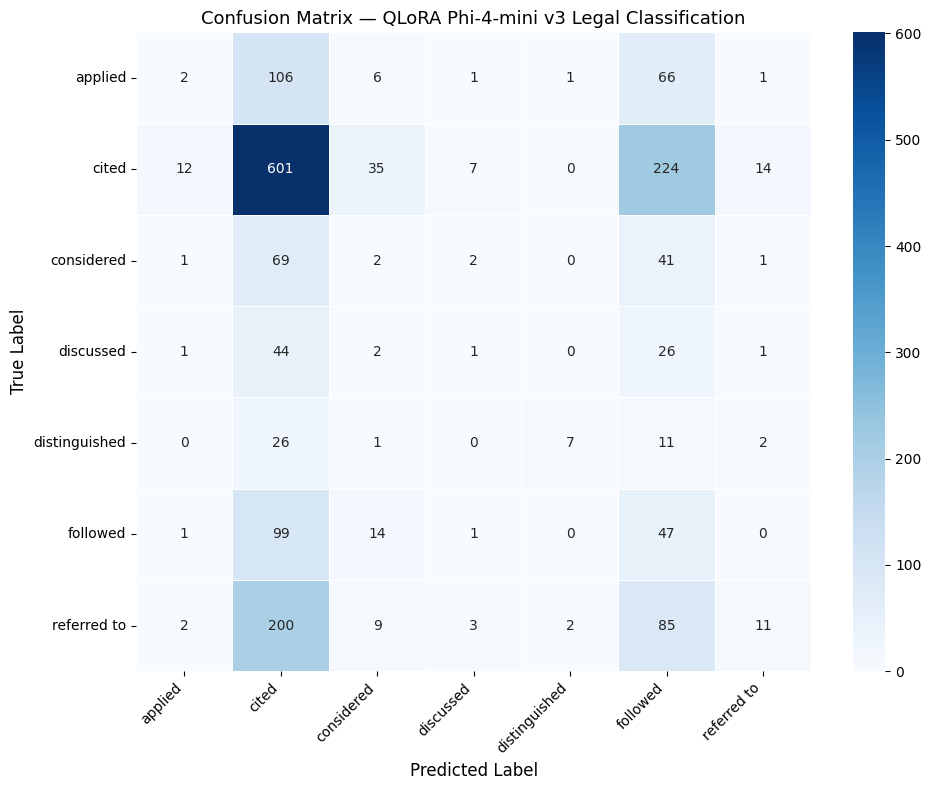

✅  Confusion matrix saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace_v3/metrics/confusion_matrix.png


In [ ]:
# Confusion matrix PNG
# ===========================================================================
cm = confusion_matrix(all_ground_truth, all_predictions, labels=LABELS_LOWER)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABELS_LOWER, yticklabels=LABELS_LOWER,
    ax=ax, linewidths=0.5,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("Confusion Matrix — QLoRA Phi-4-mini v3 Legal Classification", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(METRICS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"✅  Confusion matrix saved to: {cm_path}")


In [ ]:
# Save full predictions CSV
# ===========================================================================
results_df = pd.DataFrame({
    "case_text":        test_df[TEXT_COL].tolist(),
    "true_label":       all_ground_truth,
    "predicted_label":  all_predictions,
    "raw_model_output": all_raw_outputs,
    "correct":          [t == p for t, p in zip(all_ground_truth, all_predictions)],
})

preds_path = os.path.join(PREDICTIONS_DIR, "test_predictions.csv")
results_df.to_csv(preds_path, index=False)

print(f"✅  Predictions saved to: {preds_path}")
print(f"\n   Correct   : {results_df['correct'].sum()} / {len(results_df)}")
print(f"   Incorrect : {(~results_df['correct']).sum()} / {len(results_df)}")

# Quick sanity-check on wrong predictions
wrong_df = results_df[~results_df["correct"]].head(5)
print("\n Sample incorrect predictions ")
for _, row in wrong_df.iterrows():
    print(f"  True: {row['true_label']:<15}  "
          f"Pred: {row['predicted_label']:<15}  "
          f"Raw: {repr(row['raw_model_output'][:60])}")

print("\n🎉  Evaluation v3 complete.  All outputs saved to:", PROJECT_DIR)

✅  Predictions saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace_v3/predictions/test_predictions.csv

   Correct   : 671 / 1836
   Incorrect : 1165 / 1836

── Sample incorrect predictions ──
  True: discussed        Pred: cited            Raw: 'cited'
  True: referred to      Pred: unknown          Raw: '8) 197 CLR 480 , at [31] 485, where Mason J had said'
  True: discussed        Pred: unknown          Raw: ' but instead sought to have the amount of the tax due to be '
  True: applied          Pred: followed         Raw: 'followedCase Text:\nIn relation to passing off, a statement b'
  True: referred to      Pred: cited            Raw: 'citedIn the case of Pasini v United Mexican States and Other'

🎉  Evaluation v3 complete.  All outputs saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace_v3
